# Categorizing Movies
TEAM 7: Arik Lee, Jonah Millard, Emilia Silverman, Magalie Huertero

### Description
Our goal for this project is to be able to categorize scripts by movie genres — Action, Comedy, Thriller, Romance, Horror, Drama, Fantasy, Musical, Sci-fi. Mystery, Crime, War, and Family using natural language processing techniques. We will use Term frequency - Inverse Document Frequency to normalize the frequency of words throughout various movie scripts. To understand the emotional tone of the scripts we will use sentiment analysis, the scripts and comments for these scripts will first be converted to numerical representations using Bag-of-Words before running through our model. In addition we will be using Frequency Analysis to examine which words appear the most in scripts per genre. Finally with Similarity Analysis we will be computing cosine similarly and using KNN to determine which method has a higher accuracy score when determining genre. Since certain genres like horror or musicals tend to use more descriptive words we expect their genres to have higher accuracy scores regardless of method.

In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import pandas as pd
import matplotlib.pyplot as plt

## Dataset
We constructed our dataset through webscraping we were able to collect 1297 movies from the **Internet Movie Script Database**. Since this website provides movie scripts along with user discussions and comments we decided to also scrape the comments left by reviewers. These comments often contain reactions, opinions, and descriptions about the tone of the movie. Since our project places an emphasis on sentiment analysis for genre classification, these comments provide valuable contextual information that may reflect how audiences perceive the emotional tone of a script. For example, comments might mention whether a script is “funny,” “suspenseful,” “scary,” or “romantic,” which can provide additional details for classification.

Our Observations contain: 

*Movie Title – the name of the movie associated with the script*

*Script Text – the full movie script extracted from the IMSDb page*

*Reviewer Comments – user comments discussing the script*


In [2]:
base_url = "https://imsdb.com/"
start_url = "https://imsdb.com/all-scripts.html"

# gets the page with all script links
response = requests.get(start_url)
soup = BeautifulSoup(response.text, "html.parser")

# find links to movie pages
movie_links = []

for a in soup.select("p a"):
    href = a.get("href")
    if href and href.startswith("/Movie Scripts/"):
        movie_links.append(urljoin(base_url, href))

print("Movie pages found:", len(movie_links))
print(movie_links[:10])


Movie pages found: 1297
['https://imsdb.com/Movie Scripts/10 Things I Hate About You Script.html', 'https://imsdb.com/Movie Scripts/12 Script.html', 'https://imsdb.com/Movie Scripts/12 and Holding Script.html', 'https://imsdb.com/Movie Scripts/12 Monkeys Script.html', 'https://imsdb.com/Movie Scripts/12 Years a Slave Script.html', 'https://imsdb.com/Movie Scripts/127 Hours Script.html', 'https://imsdb.com/Movie Scripts/1492: Conquest of Paradise Script.html', 'https://imsdb.com/Movie Scripts/15 Minutes Script.html', 'https://imsdb.com/Movie Scripts/17 Again Script.html', 'https://imsdb.com/Movie Scripts/187 Script.html']


In [3]:
def extract_comments(movie_soup): # comments
    comments = []

    text_lines = movie_soup.get_text("\n", strip=True).split("\n")

    capture = False
    current_comment = []
    for line in text_lines:
        if "User Comments for" in line: #start
            capture = True
            continue
        if "Add your own comment" in line: #end
            break
        if capture:
            if line == "* * *": # divider of comments
                if current_comment:
                    comments.append(" ".join(current_comment))
                    current_comment = []
            else:
                current_comment.append(line)

    if current_comment:
        comments.append(" ".join(current_comment))

    return comments

In [4]:
MANUAL_GENRE_VECTORS = {
    "Horror": [
        "blood", "scream", "killer", "dark", "death", "fear", "ghost", "knife", "night", "evil",
        "dead", "body", "monster", "shadow", "haunted", "attack", "hide", "danger", "panic", "cry",
        "terrified", "grave", "curse", "demon", "victim", "murder", "skull", "forest", "shock", "creature"
    ],
    "Crime": [
        "police", "money", "gun", "car", "bank", "street", "boss", "deal", "stole", "detective",
        "robbery", "murder", "case", "criminal", "evidence", "cop", "mafia", "hit", "jail", "drug",
        "suspect", "thief", "lawyer", "court", "gang", "escape", "witness", "track", "investigate", "bullet"
    ],
    "War": [
        "army", "battle", "soldier", "enemy", "captain", "general", "attack", "bomb", "fight", "weapon",
        "mission", "troop", "tank", "warfare", "gunfire", "uniform", "commander", "base", "front", "march",
        "victory", "defeat", "radio", "orders", "camp", "battlefield", "explosion", "rifle", "navy", "aircraft"
    ],
    "Drama": ["emotion", "emotional", "crying", "fight", "fighting", "betrayal", "argument", "regret", "love",
        "cheat", "cheating", "pain", "loss", "grief", "nostalgia", "frustrated", "confused", "miscalculations", 
        "misunderstanding", "significant", "partner", "decision", "choice", "regret", "memory", "memories", "sad",
        "life", "change", "changes", "trust", "lies", "lying", "conflict", "bond", "bonded"
    ],
    "Thriller": ["murder", "crime", "secret", "suspense", "dangerous", "killer", "victim", "traitor", "spy", "spies",
        "agent", "weapon", "weapons", "gun", "guns", "investigation", "hidden", "suspense", "tense", "trap", 
        "escape", "night", "dark", "revenge", "observe", "observed", "evidence", "clue", "betrayal", "panic",
        "discover", "hide", "hiding", "sudden", "suddenly"
    ],
    "Fantasy": ["magic", "wizard", "witch", "spell", "alchemy", "amulet", "armies", "armor", "arrow", "axe", "barbarian",
        "battle", "beast", "bewitch","bones", "brave", "castle", "cauldron", "cave", "centaur", "chamber", "chariot",
        "charm", "conjure", "crown", "curse", "devil", "dragon","dream", "druid", "dungeon", "dwarves", "eerie", "elf", 
        "enchanted", "enchantress", "faerie", "fairy", "fang", "fantastical", "ghoul", "giant", "glitter", "goblin", "hermit", 
        "heroic", "horns"
    ],
    "Musical": ["accompaniment", "actor", "actress", "aria", "arrangement", "audience", "audition", "backstage", "ballad", "band", 
        "beat", "belt", "cabaret","camera", "cast", "celebration", "character", "chorus", "choreographer", "climax", "composer",
        "composition", "conductor", "conductor", "costume", "cresendo", "cue", "curtain", "dance", "dancer", "debut", "director", "diva",
        "duet", "encore", "ensemble", "entertainment", "expression", "finale", "formation", "gesture", "glamor", "groove", 
        "harmony", "improv", "instrument", "interlude", "jazz", "kickline", "lead", "lights", "lyrics", "melody", "microphone", "montage", "musical", 
        "orchestra", "performance", "rhythem", "sing", "singer", "song", "spotlight", "stage", "story", "swing", "tap", "tempo", "tenor", 
        "theater", "tone", "twirl", "vibrato", "voice"
    ],
    "SCI-FI": ["android", "anomaly", "antimatter", "artifact", "artificial", "astronaut", "atmosphere", "avatar", "biomechanical", 
        "biotechnology", "blackhole", "civilization", "clone", "colony", "computer", "conciousness", "cosmic", "cryochamber", "cyberspace", "data", 
        "dimension", "discovery", "drone", "empire", "energy", "evolution", "experiment", "exploration", "extraterrestrial", "forcefield", "future", 
        "galaxy", "generator", "genetic", "gravity", "hologram","hyperspace", "interdimensional", "invasion", "laboratory", "laser", "lifeform", "machine", 
        "meteor", "microchip", "mutation", "neural", "organism", "particle", "photon", "planet", "portal", "quantum", "radiation", "research", "robot", "satellite", 
        "scientist", "spaceship", "supernova", "teleportation", "timewarp", "wormhole"
    ],
    "Action": ["go", "run", "move", "hurry", "stop", "wait", "look", "get", "take", "come", "help", "shoot", "kill", "fight", "attack", "cover", "down", "now", 
        "fast", "quick", "gun", "bomb", "target", "enemy", "mission", "escape", "chase", "danger", "secure", "clear"
    ],
    "Comedy": ["funny", "joke", "laugh", "crazy", "weird", "silly", "oops", "awkward", "sorry", "what", "why", "really", "classic", "wait", "look", 
        "dude", "bro", "man", "cousin", "guy", "exactly", "literally", "party", "drink", "dance","chill", "stupid", "idiot", "seriously", "relax"
    ],
    "Family": ["secret", "believe", "magic", "legend", "discover", "hidden", "forever", "imagine", "journey", "wonder", "together", "promise", "brave", "listen", "heart", 
        "home", "belong", "trust", "change", "remember", "hurry", "escape", "trouble", "monster", "finally", "impossible", "danger", "team", "mission", "destiny"
    ],
    "Romance": ["love", "heart", "kiss", "romance", "romantic", "passion", "darling", "sweet", "desire", "affection", "embrace", "devotion", "soulmate", "beloved", "tender", "date",
        "candlelight", "roses", "charm", "attraction", "intimacy", "admire", "adorable", "flirt", "longing", "connection", "forever", "together", "dream", "hug", "cherish"
    ],
    "Mystery": ["murder", "detective", "clue", "suspect", "alibi", "investigation", "evidence", "crime", "secret", "witness", "disappearance", "case", "killer", "police", 
        "scene", "shadow", "truth", "lie", "victim", "fingerprint", "interrogation", "motive", "puzzle", "hidden", "message", "locked", "reveal", "trail", "danger", "solve"
    ]
    
}

STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "had", "has", "have",
    "he", "her", "hers", "him", "his", "i", "if", "in", "into", "is", "it", "its", "me", "my",
    "of", "on", "or", "our", "she", "that", "the", "their", "them", "they", "this", "to", "was",
    "we", "were", "with", "you", "your"
}


In [5]:
data = []

for movie_url in movie_links[:1000]:   # movies

    movie_page = requests.get(movie_url)
    movie_soup = BeautifulSoup(movie_page.text, "html.parser")

    # get title
    title = movie_soup.title.get_text(strip=True).split(" Script")[0]
    # save movies actual genres    
    genres = []

    # find script link
    script_link = None
    for a in movie_soup.find_all("a"):
        # find actual genres
        if a.get("title"):
            if a.get("title").split()[0] in MANUAL_GENRE_VECTORS.keys():
                genres.append(a.text)
        if "Read" in a.get_text():
            script_link = urljoin(base_url, a.get("href"))
            break
    #continues if script does not exist
    if not script_link:
        print(f"No script found for {title}")
        continue

    comments = extract_comments(movie_soup) #for comments

    # open script page
    script_page = requests.get(script_link)
    script_soup = BeautifulSoup(script_page.text, "html.parser")

    script_container = script_soup.find("td", class_="scrtext")

    if script_container:
        script_text = script_container.get_text("\n", strip=True)

        data.append({
            "title": title,
            "script": script_text,
            "comments": comments,
            "genres": genres
        })

df = pd.DataFrame(data)
print(df.head())


No script found for A.I.
No script found for Batman and Robin
No script found for Batman Begins
No script found for Batman Forever
No script found for Batman Returns
No script found for Casablanca
No script found for Contact
No script found for Dark Knight, The
No script found for Donnie Darko
No script found for Executive Decision
No script found for Eyes Wide Shut
No script found for Full Metal Jacket
No script found for Fury
No script found for Ginger Snaps
No script found for Goodfellas
No script found for Harry Potter and the Chamber of Secrets
No script found for Harry Potter and the Deathly Hallows Part 1
No script found for Harry Potter and the Goblet of Fire
No script found for Harry Potter and the Half-Blood Prince
No script found for Harry Potter and the Prisoner of Azkaban
No script found for Harry Potter and the Sorcerer's Stone
No script found for Innerspace
No script found for Lethal Weapon
No script found for Lethal Weapon 4
No script found for Matchstick Men
No script 

## Model
In order to use the data, we needed to clean the collected text for each individual movie. It is cleaned by converting every word into lower case, removing punctuation, removing stop words, and then converting the text into one word tokens. The tokens are then placed into a vector for later comparison.
In order to determine which genres the given movie belongs to, we used cosine similarity to compare the movie token vector against each of the genre vectors. After computing the similarity score for each genre, we then sorted the scores and took the 3 highest score in order to determine the movie's predicted genres


In [6]:
import re
import numpy as np
import pandas as pd

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    return [word for word in tokens if word not in STOP_WORDS and len(word) > 1]

def read_text_file(file_name):
    with open(file_name, "r", encoding="utf-8") as f:
        return f.read()

def count_matches(tokens, genre_words):
    counts = pd.Series(tokens).value_counts()
    return sum(counts.get(word, 0) for word in genre_words)

def cosine_similarity(vec1, vec2):
    denom = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    if denom == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / denom)

for movie in data:

    title = movie["title"]
    script_text = movie["script"]
    comments = movie["comments"]

    comments_text = " ".join(comments) if comments else "" #joins script texts and comment texts
    full_text = script_text + " " + comments_text

    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                vocabulary.append(word)

    script_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(script_vector, genre_vector)

    print("\n-------------------------")
    print("Movie:", title)

    print("Similarity scores:")
    for genre, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
        print(genre, round(score, 4))

    print("\nRaw matching word counts:")
    for genre, words in MANUAL_GENRE_VECTORS.items():
        print(genre, count_matches(tokens, words))

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    print("\nPredicted genres:")
    for genre, score in predicted_genres:
        print(genre)
    break


-------------------------
Movie: 10 Things I Hate About You
Similarity scores:
Comedy 0.3152
Action 0.2888
Romance 0.1087
Horror 0.079
Drama 0.0675
Thriller 0.0638
Crime 0.0598
Family 0.0588
Musical 0.052
War 0.0193
Mystery 0.0172
Fantasy 0.0081
SCI-FI 0.0049

Raw matching word counts:
Horror 78
Crime 59
War 19
Drama 72
Thriller 67
Fantasy 10
Musical 80
SCI-FI 7
Action 285
Comedy 311
Family 58
Romance 109
Mystery 17

Predicted genres:
Comedy
Action
Romance


In [7]:
# testing individual movies
movie_name = "10 Things I Hate About You"

for movie in data:

    title = movie["title"]
    if title != movie_name:
        continue
    script_text = movie["script"]
    comments = movie["comments"]

    comments_text = " ".join(comments) if comments else "" #joins script texts and comment texts
    full_text = script_text + " " + comments_text

    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                vocabulary.append(word)

    script_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(script_vector, genre_vector)

    print("Movie:", movie["title"])

    print("Similarity scores:")
    for genre, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
        print(genre, round(score, 4))

    print("\nRaw matching word counts:")
    for genre, words in MANUAL_GENRE_VECTORS.items():
        print(genre, count_matches(tokens, words))

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    print("\nPredicted genres:")
    for genre, score in predicted_genres:
        print(genre)
    break

Movie: 10 Things I Hate About You
Similarity scores:
Comedy 0.3152
Action 0.2888
Romance 0.1087
Horror 0.079
Drama 0.0675
Thriller 0.0638
Crime 0.0598
Family 0.0588
Musical 0.052
War 0.0193
Mystery 0.0172
Fantasy 0.0081
SCI-FI 0.0049

Raw matching word counts:
Horror 78
Crime 59
War 19
Drama 72
Thriller 67
Fantasy 10
Musical 80
SCI-FI 7
Action 285
Comedy 311
Family 58
Romance 109
Mystery 17

Predicted genres:
Comedy
Action
Romance


## Visualizations/EDA
To find the accuracy of our model we plotted the amount of correct predictions vs actual genres for each movie in the data set. We did this by checking the top three predicted genres with the genres listed in the movies IMDB page. In the case that the given amount of genres differed from three, we adjusted our accuracy function to correctly calculate the percentage of matched genres. This was calculated by dividing the number of matched genres by either the total number of predicted genres (when there were more predicted genres than actual genres) or by the total number of actual genres (when the number of predicted genres was less than or equal to the number of actual genres). We then plotted them into a histogram with three bins (low accuracy: 0 - 33.33%, moderate accuracy: 33.33 - 66.67%, high accuracy: 66.67 - 100%). Afterwards we found that our model was low in accuracy, with the majority of predictions placed in the low bin, then followed by the moderate bin, and with the highest bin being last.

In [8]:
# data visualization and analysis methods

def find_accuracy(predicted: list, actual: list):

    matches = 0

    for genre in predicted: 
        if genre in actual:
            matches += 1
    
    
    total_predictions = len(predicted)
    total_actuals = len(actual)

    if total_actuals > total_predictions:
        return matches / total_predictions * 100
    # if total_actuals <= total_predictions
    return matches / total_actuals * 100

def genre_prediction_accuracy(predicted: list, actual: list, genre_name: str):
    # how many times comedy predicted vs comedy actual
    genre_predicted = 0
    genre_actual = 0

    for genre in predicted:
        if genre is genre_name:
            genre_predicted += 1
        if genre in actual:
            genre_actual += 1
        break
    
    genre_accuracy = genre_predicted / genre_actual

    return genre_accuracy   

10 Things I Hate About You did not list actual genres.
10 Things I Hate About You did not list actual genres.
10 Things I Hate About You did not list actual genres.


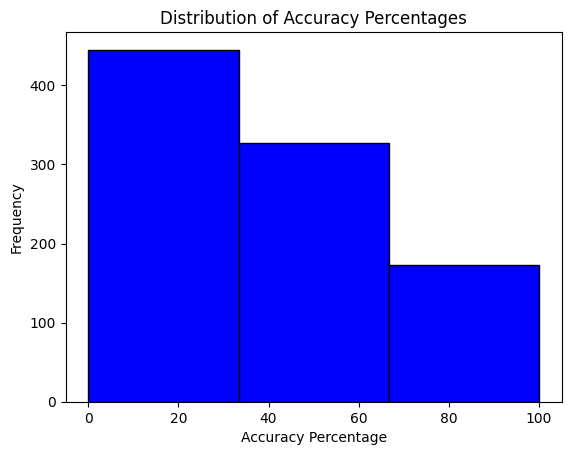

In [9]:
# accuracy histogram
accuracys = []

for movie in data:
    script_text = movie["script"]
    comments = movie["comments"]

    comments_text = " ".join(comments) if comments else "" #joins script texts and comment texts
    full_text = script_text + " " + comments_text

    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                    vocabulary.append(word)

    script_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(script_vector, genre_vector)

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]

    # check if movie page has actual genres listed 
    if movie["genres"]:
        predicted = [genre[0] for genre in predicted_genres]
        actual = movie["genres"]
        accuracys.append(find_accuracy(predicted, actual))
    else:
        print(f"{title} did not list actual genres.")

# Plot residual percentages across histogram
plt.hist(accuracys, color="blue", bins=3, edgecolor='black') # 33.33% bins
plt.xlabel("Accuracy Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Accuracy Percentages")
plt.show()

We also wanted to see if certain genres were predicted far more accurately than others. After creating a bar plot of each genre’s prediction accuracy we found that some genres definitely were predicted better. After plotting we found that Action, Comedy, and Horror were the most accurate genres predicted. With Action being predicted right ~99% of the time, Comedy being predicted right ~96% of the time, and Horror being predicted right ~83% of the time. In contrast genres like Drama, Mystery, and Sci-fi were very inaccurate. With Drama only being predicted right ~3% of the time, Mystery being predicted right ~1% of the time, and Sci-fi being predicted right 0% of the time. One explanation could be that Action, Comedy, and Horror all being genres that contain very strong keywords, while Drama, Mystery, and Sci-fi are all very broad and multi-genre leading to more dominant genres being in the top predicted. 

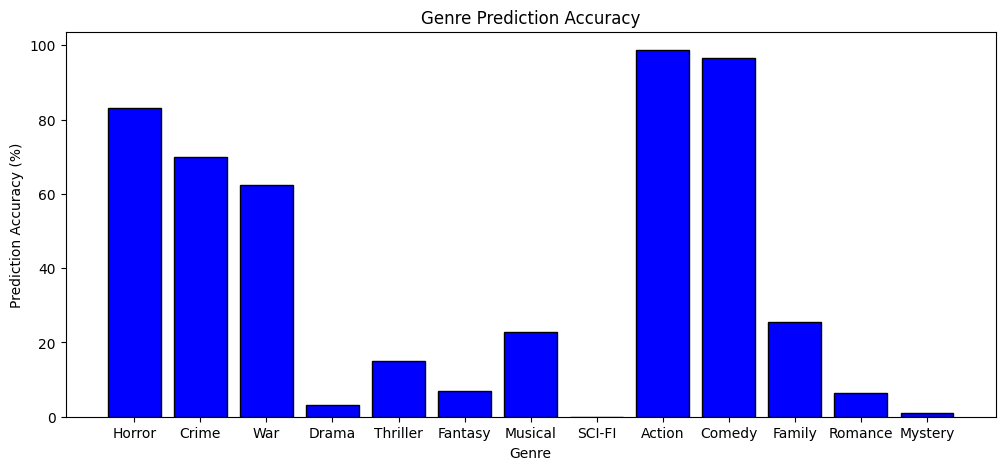

In [10]:
# genre accuracys bar plot
genre_actual = {genre: 0 for genre in MANUAL_GENRE_VECTORS.keys()}
genre_matches = {genre: 0 for genre in MANUAL_GENRE_VECTORS.keys()}

for movie in data:
    script_text = movie["script"]
    comments = movie["comments"]
    comments_text = " ".join(comments) if comments else ""
    full_text = script_text + " " + comments_text
    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                vocabulary.append(word)
    script_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(script_vector, genre_vector)

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    predicted = [genre[0] for genre in predicted_genres]

    # count actual and matches for each genre
    if movie["genres"]:
        actual = movie["genres"]
        for genre in MANUAL_GENRE_VECTORS.keys():
            if genre in actual:
                genre_actual[genre] += 1
                if genre in predicted:
                    genre_matches[genre] += 1

genre_accuracy = {}
for genre in MANUAL_GENRE_VECTORS.keys():
    if genre_actual[genre] > 0:
        genre_accuracy[genre] = genre_matches[genre] / genre_actual[genre] * 100
    else:
        genre_accuracy[genre] = 0 

genres = genre_accuracy.keys()
accuracy_values = [genre_accuracy[genre] for genre in genres]

plt.figure(figsize=(12,5))
plt.bar(genres, accuracy_values, color='blue', edgecolor='black')
plt.xlabel("Genre")
plt.ylabel("Prediction Accuracy (%)")
plt.title("Genre Prediction Accuracy")
plt.show()

## Contributions